# Homework 2

In [ ]:
# 1. Alice Signorelli ,StudentID:1000035114
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [31]:

# Helper functions

def pct_formatter(x, pos):
    return f"{x:.0%}"


def clean_spines(ax):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax

In [ ]:
# Load dataset
df = pd.read_csv("Symbol_Info_extended.csv")

df.head()

,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,1.290000e+09,7.065000e+09,0.08533,0.19946,...,25.377481,17.515205,-0.036,4.598437,4.704534,0.070,51.390,0.89,0.2205,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,1.027000e+09,1.265500e+10,0.04241,0.15427,...,18.302563,10.659156,-0.227,1.488460,2.759500,-0.052,37.019,0.56,0.1026,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,2.020000e+08,5.599400e+10,0.01846,NaN,...,44.677420,6.256155,NaN,0.163592,-2.246918,0.108,NaN,NaN,0.0000,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,8.420000e+07,6.108000e+08,0.12664,1.11725,...,30.459576,12.513987,0.264,4.175381,32.910347,0.393,346.579,0.56,0.0553,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-4.333700e+07,5.070000e+08,-0.03317,-0.06126,...,NaN,38.032272,NaN,28.724379,12.958943,0.514,25.356,NaN,0.0000,-4.455833e+08


In [9]:
print(df.shape)
df.columns.tolist()

(3070, 21)


['symbol',
 'company_name',
 'sector',
 'industry',
 'country',
 'market_cap',
 'net_income',
 'total_revenue',
 'return_on_assets',
 'return_on_equity',
 'profit_margins',
 'pe_trailing',
 'pe_forward',
 'earnings_growth',
 'price_to_sales',
 'price_to_book',
 'revenue_growth',
 'debt_to_equity',
 'dividend_yield',
 'payout_ratio',
 'free_cashflow']

<h1 style="color:green;">
Step 0 
</h1>

 I decided to select AstraZeneca PLC (AZN) for this analysis.
 It is one of the largest companies in the United Kingdom and operates
 in the pharmaceutical industry.
 The company has a very large market capitalization and strong profitability,
 with profit margins above 17% and return on equity above 23%.
 I also chose AstraZeneca because its industry includes many important
 competitors, making it easier to compare the company with similar firms
 during the following steps of the homework.

In [14]:
selected_company = "AZN"

print(selected_company)

AZN


<h1 style="color:green;">
Step 1 — Data Preparation
</h1>

In [21]:
columns_needed = [
    "symbol",
    "company_name",
    "sector",
    "industry",
    "country",
    "market_cap",
    "return_on_assets",
    "return_on_equity",
    "profit_margins",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow"
]

df_work = df[columns_needed].copy()


# replacing infinite values with NaN.

df_work = df_work.replace(
    [np.inf, -np.inf],
    np.nan
)

# Companies with a valid market cap for peer selection.

df_peers = df_work[
    df_work["market_cap"] > 0
].copy()

# Negative valuation multiples are not comparable
# with positive values and are treated as missing.

df_work.loc[
    df_work["pe_trailing"] <= 0,
    "pe_trailing"
] = np.nan

df_work.loc[
    df_work["price_to_book"] <= 0,
    "price_to_book"
] = np.nan

In [20]:
# Check the cleaned dataframe.

print(df_work.shape)

df_work.head()

(3070, 14)


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08


<h1 style="color:green;">
Step 2 — Build Peer Groups
</h1>

In [22]:
# Selected company.

selected_company = "AZN"

selected_row = df_work[
    df_work["symbol"] == selected_company
]

selected_row

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
300,AZN,AstraZeneca PLC,Healthcare,Drug Manufacturers - General,United Kingdom,2.900551e+11,0.08487,0.23483,0.17189,28.16717,6.120693,0.125,71.815,6.558875e+09


In [23]:
selected_industry = selected_row["industry"].iloc[0]
selected_country = selected_row["country"].iloc[0]
selected_market_cap = selected_row["market_cap"].iloc[0]

print(selected_industry)
print(selected_country)
print(selected_market_cap)

Drug Manufacturers - General
United Kingdom
290055127040.0


In [24]:
# Group A: same industry.

group_a = (
    df_peers[
        df_peers["industry"] == selected_industry
    ]
    .sort_values(
        by="market_cap",
        ascending=False
    )
)

# Keep top 10 companies.

group_a = group_a.head(10)

# Add AstraZeneca if not already included.

if selected_company not in group_a["symbol"].values:
    group_a = pd.concat(
        [group_a, selected_row]
    )

group_a

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
1634,LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,United States,9.497046e+11,0.20739,1.07459,0.34986,37.873398,30.500902,0.555,139.015,9.156600e+09
1496,JNJ,Johnson & Johnson,Healthcare,Drug Manufacturers - General,United States,5.641072e+11,0.08424,0.26416,0.21834,27.185616,6.946495,0.099,67.730,1.251138e+10
9,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,United States,3.810972e+11,0.10032,NaN,0.05786,105.219510,-57.260418,0.124,NaN,2.081162e+10
1816,MRK,"Merck & Co., Inc.",Healthcare,Drug Manufacturers - General,United States,3.023312e+11,0.12578,0.18944,0.13586,34.481693,6.589686,0.049,106.936,1.404925e+10
300,AZN,AstraZeneca PLC,Healthcare,Drug Manufacturers - General,United Kingdom,2.900551e+11,0.08487,0.23483,0.17189,28.167170,6.120693,0.125,71.815,6.558875e+09
149,AMGN,Amgen Inc.,Healthcare,Drug Manufacturers - General,United States,1.831230e+11,0.08348,1.01318,0.20956,23.578873,19.926004,0.058,623.754,7.436625e+09
1182,GILD,"Gilead Sciences, Inc.",Healthcare,Drug Manufacturers - General,United States,1.668173e+11,0.13292,0.43360,0.30993,18.280272,7.096604,0.044,94.635,7.934125e+09
2131,PFE,Pfizer Inc.,Healthcare,Drug Manufacturers - General,United States,1.476156e+11,0.05687,0.08310,0.11831,19.770992,1.702939,0.054,71.602,1.237663e+10
411,BMY,Bristol-Myers Squibb Company,Healthcare,Drug Manufacturers - General,United States,1.214216e+11,0.10689,0.38732,0.15006,16.655462,6.050061,0.026,230.967,9.851750e+09
373,BIIB,Biogen Inc.,Healthcare,Drug Manufacturers - General,United States,2.860617e+10,0.05900,0.07701,0.13805,20.834408,1.533312,0.019,35.181,1.915987e+09


In [25]:
# Group B: companies from the United Kingdom.

group_b = (
    df_peers[
        df_peers["country"] == "United Kingdom"
    ]
    .sort_values(
        by="market_cap",
        ascending=False
    )
)

group_b = group_b.head(10)

if selected_company not in group_b["symbol"].values:
    group_b = pd.concat(
        [group_b, selected_row]
    )

group_b

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
218,ARM,Arm Holdings plc,Technology,Semiconductors,United Kingdom,3.261262e+11,0.05749,0.11954,0.18374,356.406980,41.741800,0.201,5.214,7.723750e+08
300,AZN,AstraZeneca PLC,Healthcare,Drug Manufacturers - General,United Kingdom,2.900551e+11,0.08487,0.23483,0.17189,28.167170,6.120693,0.125,71.815,6.558875e+09
1625,LIN,Linde plc,Basic Materials,Specialty Chemicals,United Kingdom,2.393017e+11,0.07237,0.18229,0.20436,34.367863,6.208378,0.082,65.642,4.694500e+09
523,CCEP,Coca-Cola Europacific Partners PLC,Consumer Defensive,Beverages - Non-Alcoholic,United Kingdom,4.167418e+10,0.05716,0.22894,0.09291,19.014143,4.638972,0.002,130.001,1.747875e+09
1120,FTI,TechnipFMC plc,Energy,Oil & Gas Equipment & Services,United Kingdom,2.830385e+10,0.09180,0.33407,0.10620,27.199234,8.456224,0.116,38.688,9.874500e+08
1973,NVT,nVent Electric plc,Industrials,Electrical Equipment & Parts,United Kingdom,2.662889e+10,0.06397,0.13002,0.11371,55.816948,7.013972,0.535,44.710,2.098750e+08
3011,WTW,Willis Towers Watson Public Limited Company,Financial Services,Insurance Brokers,United Kingdom,2.431091e+10,0.05089,0.20611,0.16843,15.105633,3.068413,0.085,85.693,2.052125e+09
1689,LYB,LyondellBasell Industries N.V.,Basic Materials,Specialty Chemicals,United Kingdom,2.250455e+10,0.01744,-0.06009,-0.02686,NaN,2.227334,-0.063,141.240,9.870000e+08
2355,ROIV,Roivant Sciences Ltd.,Healthcare,Biotechnology,United Kingdom,2.154934e+10,-0.14354,-0.07594,0.00000,NaN,4.980053,-0.667,2.030,-1.090485e+09
2971,WIZEY,Wise Group PLC,Technology,Information Technology Services,United Kingdom,1.449383e+10,0.01665,0.29670,0.22486,28.980000,7.843521,0.092,21.035,4.293375e+08


In [26]:
# Group C: closest market capitalization.

group_c = df_peers.copy()

group_c["market_cap_distance"] = (
    group_c["market_cap"] -
    selected_market_cap
).abs()

group_c = (
    group_c
    .sort_values(
        by="market_cap_distance"
    )
    .head(10)
)

group_c

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,market_cap_distance
300,AZN,AstraZeneca PLC,Healthcare,Drug Manufacturers - General,United Kingdom,2.900551e+11,0.08487,0.23483,0.17189,28.167170,6.120693,0.125,71.815,6.558875e+09,0.000000e+00
1235,GS,"The Goldman Sachs Group, Inc.",Financial Services,Capital Markets,United States,2.940427e+11,0.00944,0.14548,0.29363,18.215094,2.797674,0.145,678.596,NaN,3.987603e+09
2180,PM,Philip Morris International Inc.,Consumer Defensive,Tobacco,United States,2.945520e+11,0.15456,NaN,0.26742,26.580872,-29.437695,0.091,NaN,8.575250e+09,4.496916e+09
2783,TXN,Texas Instruments Incorporated,Technology,Semiconductors,United States,2.814098e+11,0.12161,0.32347,0.29108,52.946915,16.771166,0.186,83.741,1.068250e+09,8.645345e+09
1169,GEV,GE Vernova Inc.,Industrials,Specialty Industrial Machinery,United States,2.791302e+11,0.02384,0.75708,0.23810,30.399181,20.049414,0.163,24.925,9.315625e+09,1.092492e+10
1816,MRK,"Merck & Co., Inc.",Healthcare,Drug Manufacturers - General,United States,3.023312e+11,0.12578,0.18944,0.13586,34.481693,6.589686,0.049,106.936,1.404925e+10,1.227611e+10
1274,HD,"The Home Depot, Inc.",Consumer Cyclical,Home Improvement Retail,United States,3.118264e+11,0.12519,1.28380,0.08411,22.219305,22.429432,0.048,455.218,1.012825e+10,2.177126e+10
2389,RY,Royal Bank of Canada,Financial Services,Banks - Diversified,Canada,2.637949e+11,0.00927,0.15395,0.33137,17.914070,2.863501,0.075,NaN,NaN,2.626024e+10
1157,GE,GE Aerospace,Industrials,Aerospace & Defense,United States,3.164162e+11,0.04852,0.45428,0.17863,37.573200,17.004885,0.247,116.527,5.668000e+09,2.636107e+10
1823,MS,Morgan Stanley,Financial Services,Capital Markets,United States,3.170816e+11,0.01270,0.16388,0.24753,18.209240,3.037716,0.163,502.246,NaN,2.702646e+10


In [27]:
print("Group A size:", len(group_a))
print("Group B size:", len(group_b))
print("Group C size:", len(group_c))

Group A size: 10
Group B size: 10
Group C size: 10


In [28]:
print(group_a[["symbol","company_name","market_cap"]])

print(group_b[["symbol","company_name","market_cap"]])

print(group_c[["symbol","company_name","market_cap"]])

     symbol                  company_name    market_cap
1634    LLY         Eli Lilly and Company  9.497046e+11
1496    JNJ             Johnson & Johnson  5.641072e+11
9      ABBV                   AbbVie Inc.  3.810972e+11
1816    MRK             Merck & Co., Inc.  3.023312e+11
300     AZN               AstraZeneca PLC  2.900551e+11
149    AMGN                    Amgen Inc.  1.831230e+11
1182   GILD         Gilead Sciences, Inc.  1.668173e+11
2131    PFE                   Pfizer Inc.  1.476156e+11
411     BMY  Bristol-Myers Squibb Company  1.214216e+11
373    BIIB                   Biogen Inc.  2.860617e+10
     symbol                                 company_name    market_cap
218     ARM                             Arm Holdings plc  3.261262e+11
300     AZN                              AstraZeneca PLC  2.900551e+11
1625    LIN                                    Linde plc  2.393017e+11
523    CCEP           Coca-Cola Europacific Partners PLC  4.167418e+10
1120    FTI                  

<h1 style="color:green;">
Step 3 — Business Question 1: Is the Company Profitable?
</h1>

In [40]:
# I start with profit margins because this metric shows how much
# profit a company keeps from its revenue.
# Here I compare AstraZeneca with the companies in Group A
# to see whether it is more or less profitable than its industry peers.

profit_a = group_a.dropna(
    subset=["profit_margins"]
).copy()
profit_a = profit_a.sort_values(
    by="profit_margins"
)

In [49]:
# Here I compare AstraZeneca with the companies in Group B,
# which contains the largest companies from the same geographic group.

profit_b = group_b.dropna(
    subset=["profit_margins"]
).copy()

In [38]:
# Here I compare AstraZeneca with companies that have a similar
# market capitalization.

profit_c = group_c.dropna(
    subset=["profit_margins"]
).copy()

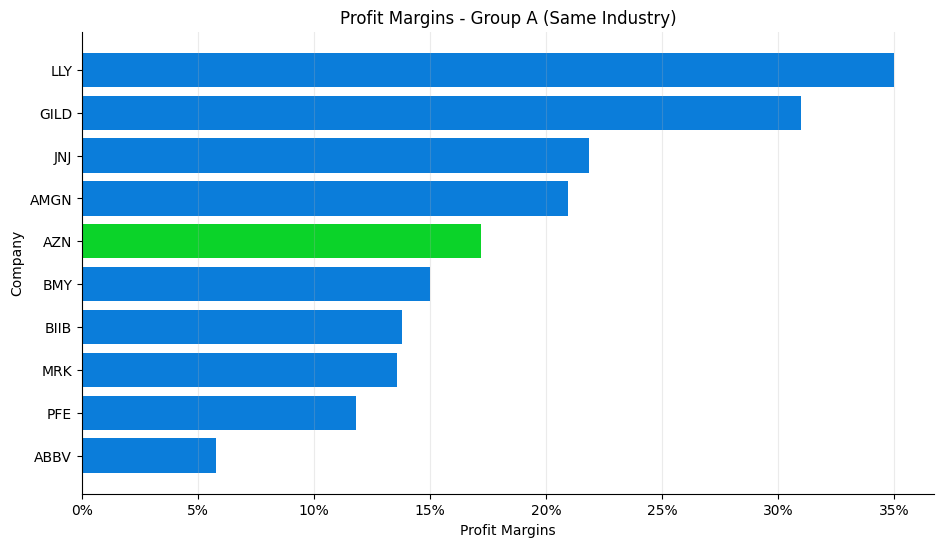

In [70]:
# AstraZeneca is highlighted in green so it can be identified easily.

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in profit_a["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    profit_a["symbol"],
    profit_a["profit_margins"],
    color=colors
)

ax.set_title(
    "Profit Margins - Group A (Same Industry)"
)

ax.set_xlabel("Profit Margins")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

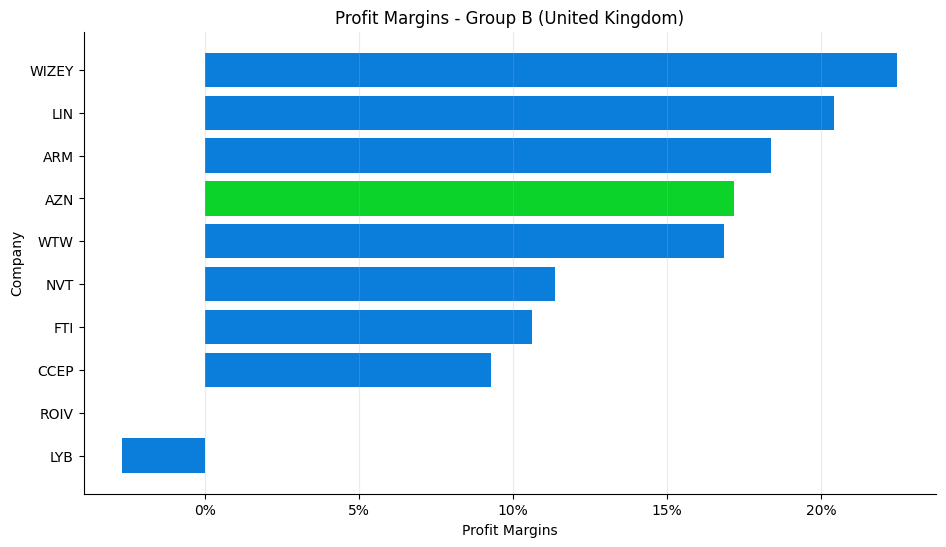

In [71]:
# I now compare AstraZeneca with the largest companies
# from the same geographic group.

profit_b = profit_b.sort_values(
    by="profit_margins"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in profit_b["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    profit_b["symbol"],
    profit_b["profit_margins"],
    color=colors
)

ax.set_title(
    "Profit Margins - Group B (United Kingdom)"
)

ax.set_xlabel("Profit Margins")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

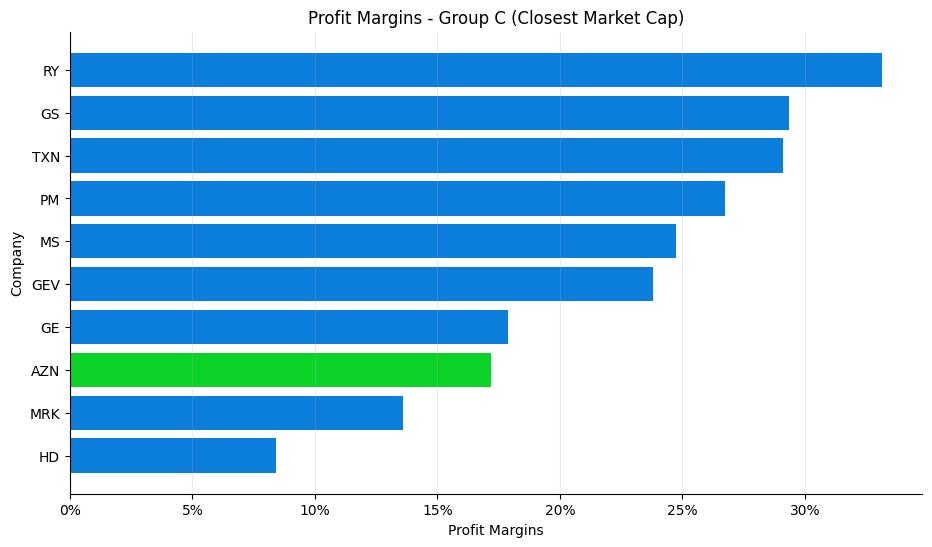

In [72]:
# I now compare AstraZeneca with companies
# that have a similar market capitalization.

profit_c = profit_c.sort_values(
    by="profit_margins"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in profit_c["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    profit_c["symbol"],
    profit_c["profit_margins"],
    color=colors
)

ax.set_title(
    "Profit Margins - Group C (Closest Market Cap)"
)

ax.set_xlabel("Profit Margins")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [73]:
# I now use return on equity to evaluate how efficiently
# companies generate profits from shareholders' equity.

roe_a = group_a.dropna(
    subset=["return_on_equity"]
).copy()

roe_b = group_b.dropna(
    subset=["return_on_equity"]
).copy()

roe_c = group_c.dropna(
    subset=["return_on_equity"]
).copy()

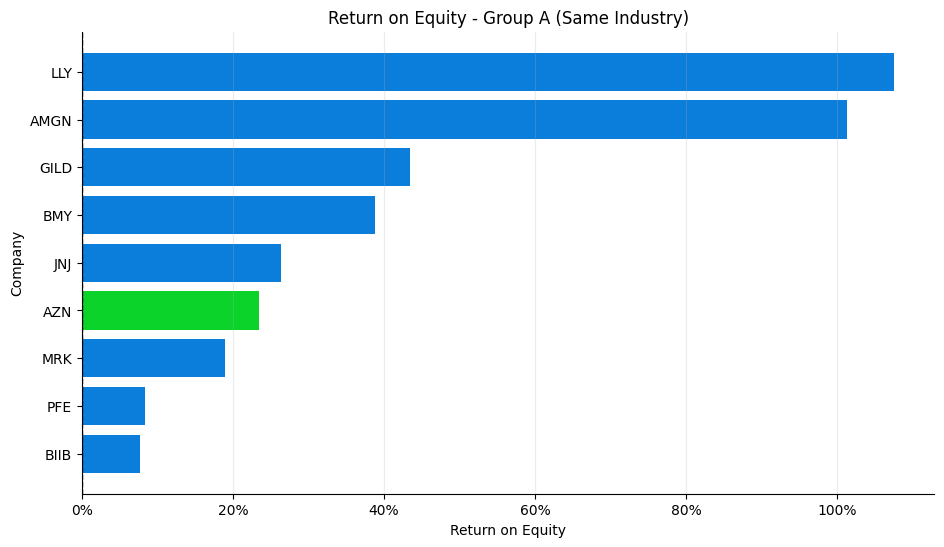

In [74]:
# Here I compare AstraZeneca with the companies in Group A
# using return on equity.

roe_a = roe_a.sort_values(
    by="return_on_equity"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in roe_a["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    roe_a["symbol"],
    roe_a["return_on_equity"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Return on Equity - Group A (Same Industry)"
)

ax.set_xlabel("Return on Equity")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

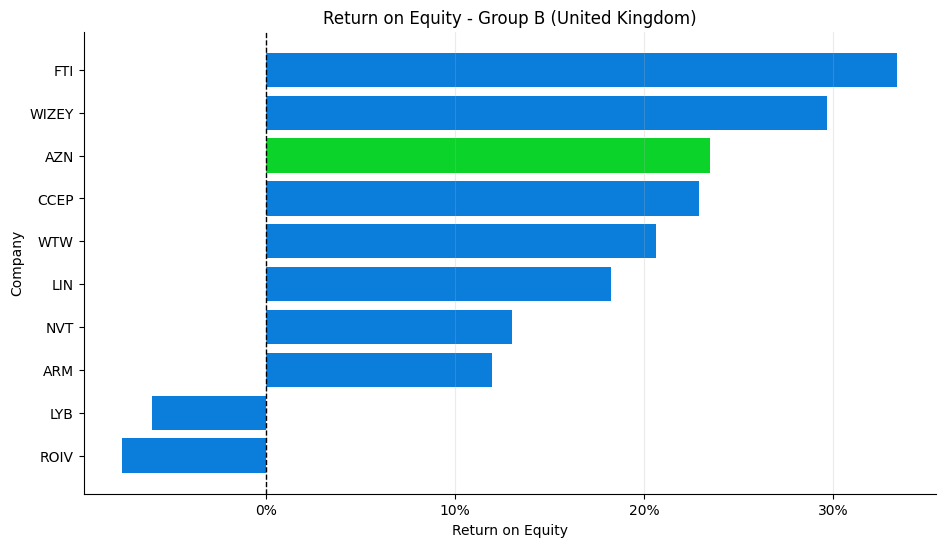

In [75]:
# Here I compare AstraZeneca with the companies in Group B
# using return on equity.

roe_b = roe_b.sort_values(
    by="return_on_equity"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in roe_b["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    roe_b["symbol"],
    roe_b["return_on_equity"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Return on Equity - Group B (United Kingdom)"
)

ax.set_xlabel("Return on Equity")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

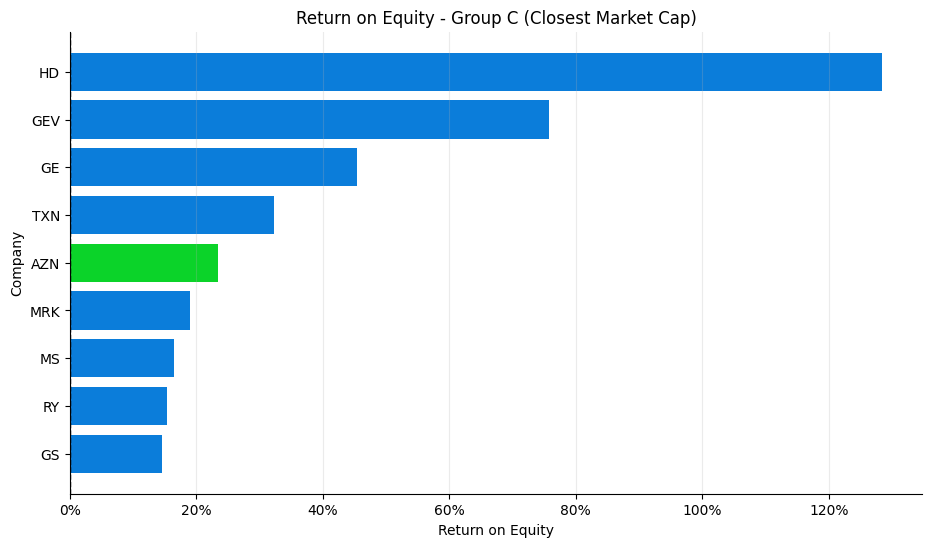

In [76]:
# Here I compare AstraZeneca with companies that have
# a similar market capitalization using return on equity.

roe_c = roe_c.sort_values(
    by="return_on_equity"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in roe_c["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    roe_c["symbol"],
    roe_c["return_on_equity"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Return on Equity - Group C (Closest Market Cap)"
)

ax.set_xlabel("Return on Equity")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [52]:
# Calculate peer medians for the profitability metrics.

print("Group A Profit Margin Median:",
      profit_a["profit_margins"].median())

print("Group B Profit Margin Median:",
      profit_b["profit_margins"].median())

print("Group C Profit Margin Median:",
      profit_c["profit_margins"].median())

print()

print("Group A ROE Median:",
      roe_a["return_on_equity"].median())

print("Group B ROE Median:",
      roe_b["return_on_equity"].median())

print("Group C ROE Median:",
      roe_c["return_on_equity"].median())

Group A Profit Margin Median: 0.160974995
Group B Profit Margin Median: 0.14107
Group C Profit Margin Median: 0.242814995

Group A ROE Median: 0.26416
Group B ROE Median: 0.19419999999999998
Group C ROE Median: 0.23482999


AstraZeneca shows strong profitability overall. Its profit margin is above the median of both Group A and Group B, which suggests that the company is able to generate more profit from its revenue than many of its industry and geographic peers. However, its profit margin is lower than the median of Group C, which contains companies with a similar market capitalization.

Looking at return on equity, AstraZeneca performs slightly below the median of Group A but above the median of Group B. Compared with Group C, its ROE is almost identical to the median value. This indicates that the company uses shareholders' equity efficiently, although some competitors in the pharmaceutical industry achieve even higher returns.

Overall, the two metrics tell a consistent story. AstraZeneca appears to be a profitable company with solid financial performance and results that are generally in line with or above those of most peer groups.


<h1 style="color:green;">
Step 4 — Business Question 2: Is the Company Expensive or Cheap?
</h1>

In [77]:
# I start with the trailing P/E ratio.
# This metric shows how much investors are willing to pay
# for each dollar of earnings.

pe_group = group_a.dropna(
    subset=["pe_trailing"]
).copy()

pe_group = pe_group.sort_values(
    by="pe_trailing"
)

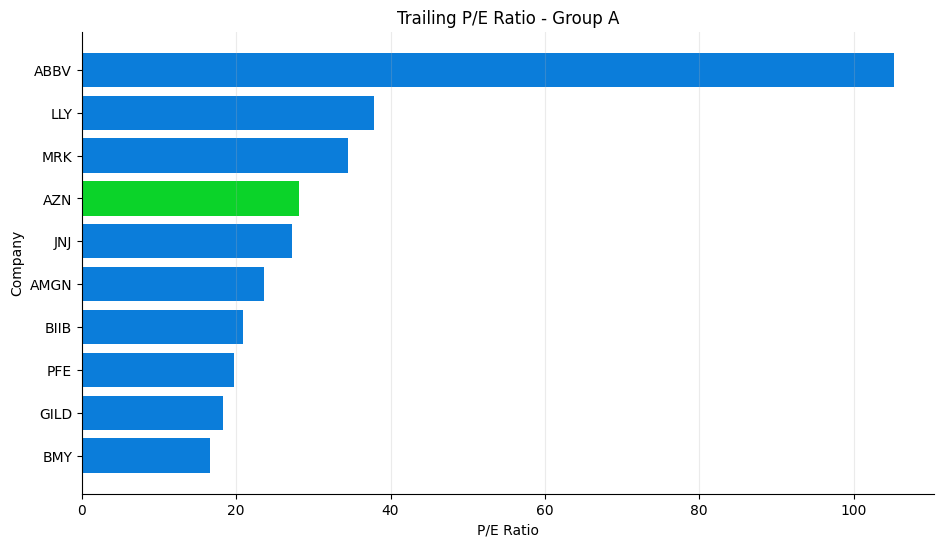

In [78]:
# AstraZeneca is highlighted in green.

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in pe_group["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    pe_group["symbol"],
    pe_group["pe_trailing"],
    color=colors
)

ax.set_title(
    "Trailing P/E Ratio - Group A"
)

ax.set_xlabel("P/E Ratio")
ax.set_ylabel("Company")

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [55]:
# I now analyze the price-to-book ratio.
# This metric compares the market value of a company
# with its book value.

pb_group = group_a.dropna(
    subset=["price_to_book"]
).copy()

pb_group = pb_group.sort_values(
    by="price_to_book"
)

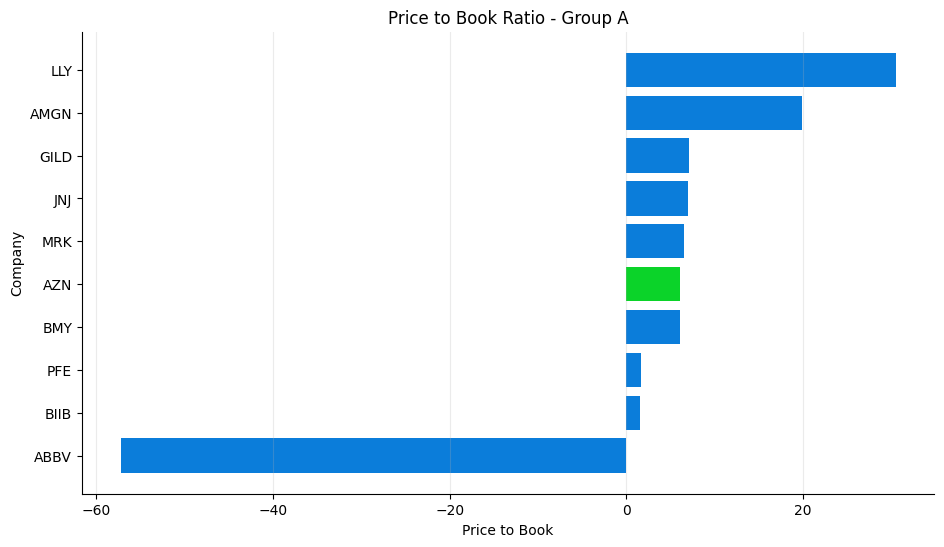

In [79]:
# AstraZeneca is highlighted in green.

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in pb_group["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    pb_group["symbol"],
    pb_group["price_to_book"],
    color=colors
)

ax.set_title(
    "Price to Book Ratio - Group A"
)

ax.set_xlabel("Price to Book")
ax.set_ylabel("Company")

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [57]:
print("P/E Median:",
      pe_group["pe_trailing"].median())

print("Price to Book Median:",
      pb_group["price_to_book"].median())

P/E Median: 25.3822445
Price to Book Median: 6.35518935


In [58]:
print(
    group_a.loc[
        group_a["symbol"] == selected_company,
        ["pe_trailing", "price_to_book"]
    ]
)

     pe_trailing  price_to_book
300     28.16717       6.120693


AstraZeneca appears to be fairly valued compared with its industry peers. Its trailing P/E ratio is slightly above the median of Group A, suggesting that investors are willing to pay a small premium for the company's earnings. This may reflect its strong profitability and stable position in the pharmaceutical industry.

The price-to-book ratio is very close to the peer median, indicating that AstraZeneca is valued similarly to most companies in the group when compared with its book value.

Overall, the company does not appear particularly cheap, but it does not look excessively expensive either. The valuation seems consistent with its solid profitability observed in Step 3. Therefore, the current valuation is more likely linked to strong fundamentals than to market overpricing. There is also no clear evidence that a lower valuation is hiding weak fundamentals, since AstraZeneca showed good profit margins and a strong return on equity compared with most peer groups.


<h1 style="color:green;">
Step 5 — Business Question 3: Is the Company Growing?
</h1>

In [80]:
# I use revenue growth to evaluate whether AstraZeneca
# is growing faster or slower than its peers.

growth_a = group_a.dropna(
    subset=["revenue_growth"]
).copy()

growth_b = group_b.dropna(
    subset=["revenue_growth"]
).copy()

growth_c = group_c.dropna(
    subset=["revenue_growth"]
).copy()

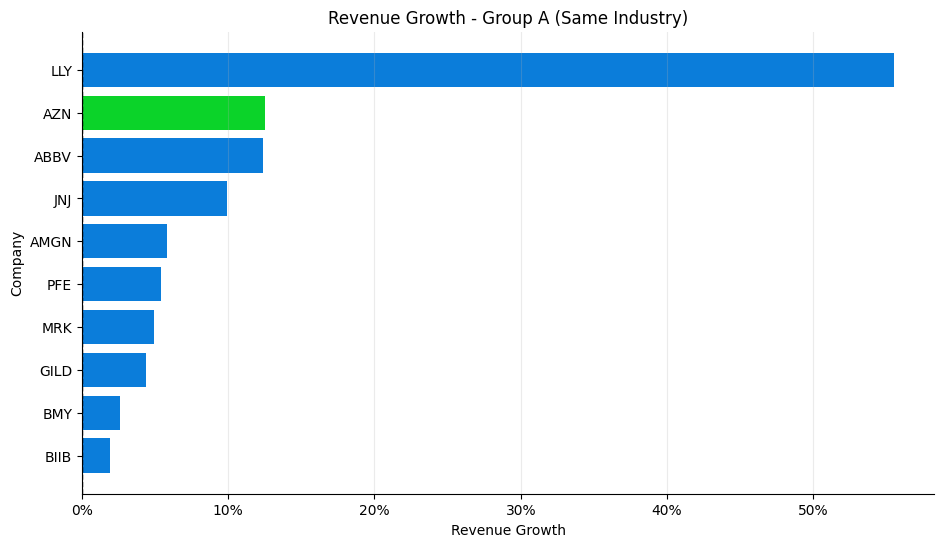

In [81]:
# Here I compare AstraZeneca with companies
# from the same industry using revenue growth.

growth_a = growth_a.sort_values(
    by="revenue_growth"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in growth_a["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    growth_a["symbol"],
    growth_a["revenue_growth"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Revenue Growth - Group A (Same Industry)"
)

ax.set_xlabel("Revenue Growth")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

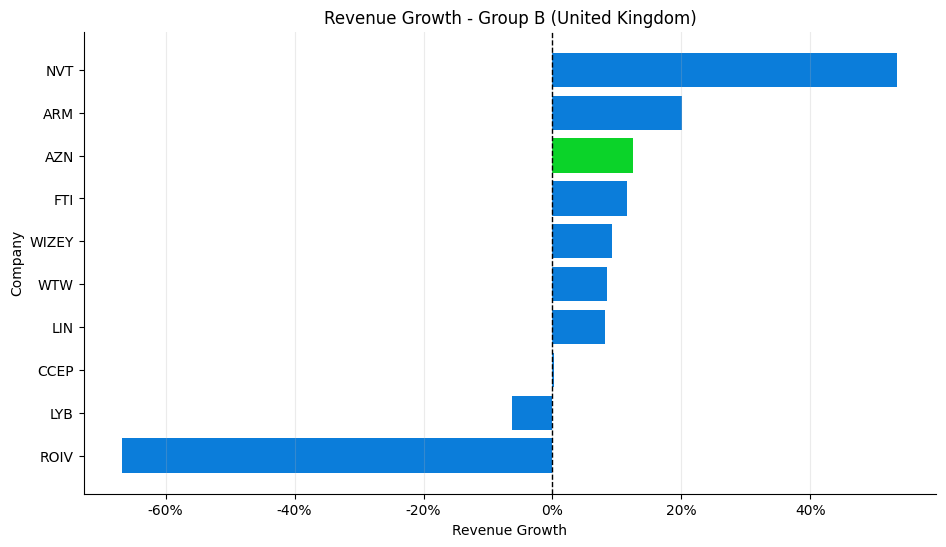

In [82]:
# Here I compare AstraZeneca with the largest companies
# from the same geographic group.

growth_b = growth_b.sort_values(
    by="revenue_growth"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in growth_b["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    growth_b["symbol"],
    growth_b["revenue_growth"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Revenue Growth - Group B (United Kingdom)"
)

ax.set_xlabel("Revenue Growth")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

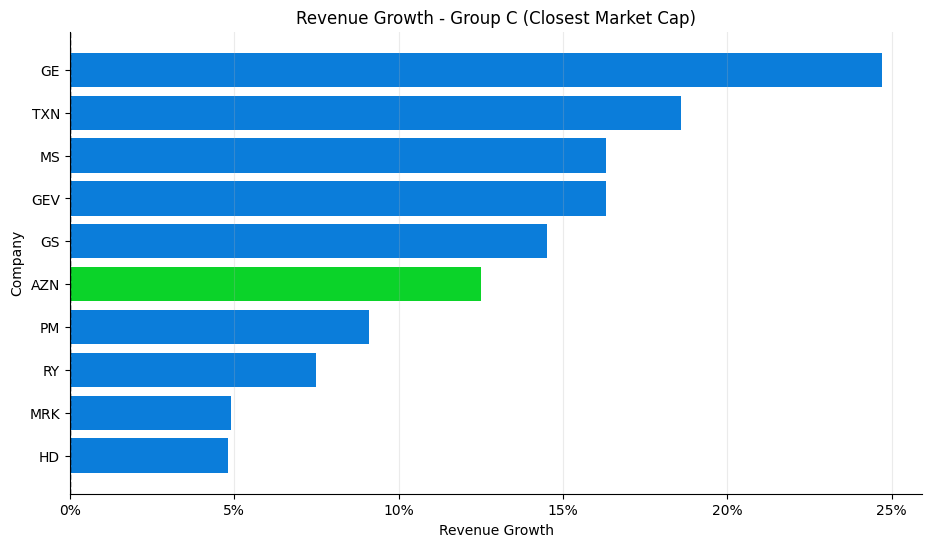

In [83]:
# Here I compare AstraZeneca with companies
# that have a similar market capitalization.

growth_c = growth_c.sort_values(
    by="revenue_growth"
)

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in growth_c["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    growth_c["symbol"],
    growth_c["revenue_growth"],
    color=colors
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Revenue Growth - Group C (Closest Market Cap)"
)

ax.set_xlabel("Revenue Growth")
ax.set_ylabel("Company")

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [84]:
print("Group A Revenue Growth Median:",
      growth_a["revenue_growth"].median())

print("Group B Revenue Growth Median:",
      growth_b["revenue_growth"].median())

print("Group C Revenue Growth Median:",
      growth_c["revenue_growth"].median())

print()

print(
    growth_a.loc[
        growth_a["symbol"] == selected_company,
        "revenue_growth"
    ].iloc[0]
)

Group A Revenue Growth Median: 0.056
Group B Revenue Growth Median: 0.0885
Group C Revenue Growth Median: 0.135

0.125


AstraZeneca shows positive revenue growth of 12.5%, indicating that the company is continuing to expand its business. The growth rate is well above the median of both Group A and Group B, suggesting that AstraZeneca is growing faster than many of its industry and geographic peers.

Compared with Group C, which contains companies with a similar market capitalization, AstraZeneca's growth rate is slightly below the median but still remains very strong.

These results help explain the valuation observed in Step 4. AstraZeneca's P/E ratio was slightly above the industry median, and its solid revenue growth may justify part of this premium. Investors are often willing to pay a higher valuation for companies that combine profitability with consistent growth. Overall, the company appears to have a healthy growth profile and does not show signs of declining revenue.


<h1 style="color:green;">
Step 6 — Business Question 4: Is the Company Financially Solid?
</h1>

In [65]:
debt_group = group_a.dropna(
    subset=["debt_to_equity"]
).copy()

debt_group = debt_group.sort_values(
    by="debt_to_equity"
)

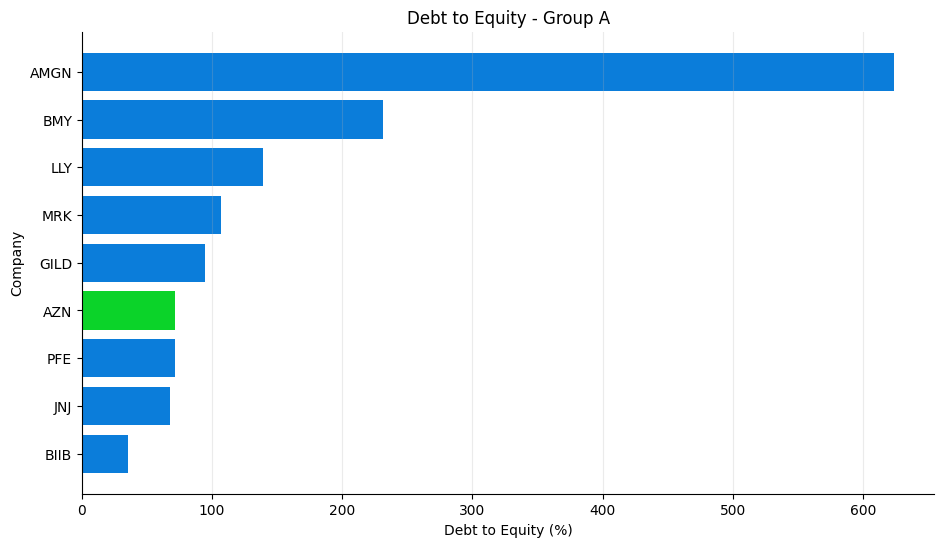

In [85]:
# AstraZeneca is highlighted in red.

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in debt_group["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    debt_group["symbol"],
    debt_group["debt_to_equity"],
    color=colors
)

ax.set_title(
    "Debt to Equity - Group A"
)

ax.set_xlabel("Debt to Equity (%)")
ax.set_ylabel("Company")

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [86]:
# I now analyze free cash flow.
# This metric shows how much cash a company generates
# after covering its operating and investment expenses.

fcf_group = group_a.dropna(
    subset=["free_cashflow"]
).copy()

fcf_group = fcf_group.sort_values(
    by="free_cashflow"
)

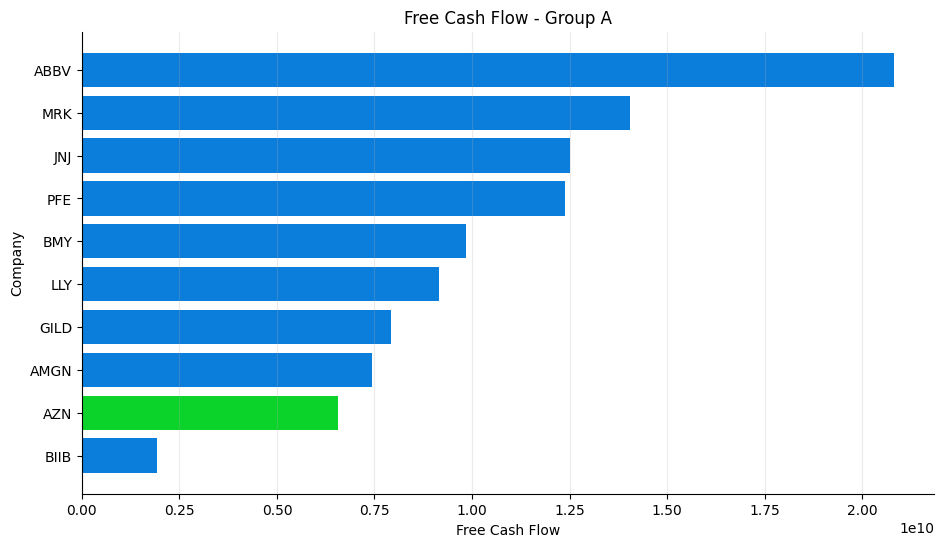

In [87]:
# AstraZeneca is highlighted in green.

colors = [
    "#0BD329" if symbol == selected_company else "#0B7DDA"
    for symbol in fcf_group["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    fcf_group["symbol"],
    fcf_group["free_cashflow"],
    color=colors
)

ax.set_title(
    "Free Cash Flow - Group A"
)

ax.set_xlabel("Free Cash Flow")
ax.set_ylabel("Company")

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [88]:
print("Debt to Equity Median:",
      debt_group["debt_to_equity"].median())

print("Free Cash Flow Median:",
      fcf_group["free_cashflow"].median())

print()

print(
    group_a.loc[
        group_a["symbol"] == selected_company,
        ["debt_to_equity", "free_cashflow"]
    ]
)

Debt to Equity Median: 94.635
Free Cash Flow Median: 9504175104.0

     debt_to_equity  free_cashflow
300          71.815   6.558875e+09


AstraZeneca seems to have a solid financial position overall. Its debt-to-equity ratio is lower than the median of Group A, which suggests that the company relies less on debt than many of its industry peers. This indicates a balanced financial structure and a lower dependence on borrowing.

The company also generates positive free cash flow, meaning that it is able to produce cash after covering its operating and investment costs. Even though AstraZeneca's free cash flow is below the median of the peer group, it is still strongly positive and does not appear to be a concern.

Overall, the results suggest that AstraZeneca is financially strong. The company combines a moderate level of debt with positive cash generation, which reduces financial risk and provides resources that can support future growth and investments.



<h1 style="color:green;">
Final Summary
</h1>


For this analysis I selected AstraZeneca PLC because it is one of the largest companies in the United Kingdom and operates in the pharmaceutical industry. Another reason for choosing this company was the availability of a strong peer group, including several major pharmaceutical companies. The experience from Homework 1 also influenced my choice, since I found it useful to analyze a company with solid profitability and enough comparable firms to make the peer analysis meaningful.

Looking at profitability, AstraZeneca performed well compared with most peer groups. Its profit margins were above the median of both the industry group and the geographic group, while its return on equity was above the geographic group median and close to the median of companies with a similar market capitalization. Overall, the profitability metrics showed a consistent picture of a company with strong operating performance.

The valuation analysis suggested that AstraZeneca is fairly valued. Its trailing P/E ratio was slightly above the industry median, while its price-to-book ratio was very close to the peer median. This indicates that investors are willing to pay a small premium for the company, but not an excessive one. The growth analysis helps explain this valuation. AstraZeneca reported revenue growth of 12.5%, which was higher than the median of both the industry and geographic peer groups. This combination of profitability and growth supports the company's valuation.

The financial strength analysis also produced positive results. AstraZeneca's debt-to-equity ratio was below the industry median, suggesting a lower reliance on debt than many competitors. The company also generated positive free cash flow, which indicates an ability to produce cash after covering its operating and investment activities. Although its free cash flow was below the industry median, it remained strongly positive and did not raise significant concerns.

No major issues related to missing data affected the analysis. Some valuation metrics required cleaning according to the homework instructions, but valid observations were available for AstraZeneca across all the key metrics used in the study. As a result, the analysis could be completed without excluding the company from any of the main comparisons.

Overall, AstraZeneca appears to be a profitable, growing, and financially solid company. Its valuation seems reasonable when considered alongside its profitability and growth profile, making it one of the stronger companies within its peer group.
